In [26]:
import tensorflow as tf
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
import cv2
import numpy as np
import os
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.vgg16 import VGG16

In [27]:
train_dir = 'F:/Vignesh/Image processing/alzheimer disease detection using dl/OriginalDataset/train/'
test_dir = 'F:/Vignesh/Image processing/alzheimer disease detection using dl/OriginalDataset/test/'

In [28]:
batch_size = 1
epochs = 1
img_height = 180
img_width = 180

In [29]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [30]:
train_image_generator = ImageDataGenerator(rescale=1./255)  
train_data_gen = train_image_generator.flow_from_directory(batch_size=batch_size,directory=train_dir,shuffle=True,target_size=(img_height, img_width),class_mode='categorical')

Found 6400 images belonging to 4 classes.


In [31]:
val_image_generator = ImageDataGenerator(rescale=1./255)  
val_data_gen = val_image_generator .flow_from_directory(batch_size=batch_size,directory=test_dir,shuffle=True,target_size=(img_height, img_width),class_mode='categorical')

Found 6400 images belonging to 4 classes.


In [32]:
import warnings
 

import os
import glob
import matplotlib.pyplot as plt

# Import Keras
import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout,Flatten
from keras.layers import Conv2D,MaxPooling2D,Activation,AveragePooling2D,BatchNormalization
from keras.preprocessing.image import ImageDataGenerator

In [33]:
from tensorflow.keras.applications.xception import Xception


In [34]:
 base_model = Xception(weights = 'imagenet', include_top=False, input_shape=(224, 224, 3))


In [35]:
base_model.trainable = False

In [36]:
base_model.summary()

Model: "xception"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_3 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 block1_conv1 (Conv2D)          (None, 111, 111, 32  864         ['input_3[0][0]']                
                                )                                                                 
                                                                                                  
 block1_conv1_bn (BatchNormaliz  (None, 111, 111, 32  128        ['block1_conv1[0][0]']           
 ation)                         )                                                          

In [37]:
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, GlobalAveragePooling2D


In [38]:
xception_net = tf.keras.models.Sequential()

xception_net.add(base_model)
xception_net.add(GlobalAveragePooling2D())
xception_net.add(Dense(4, activation = 'softmax'))
xception_net.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 xception (Functional)       (None, 7, 7, 2048)        20861480  
                                                                 
 global_average_pooling2d_2   (None, 2048)             0         
 (GlobalAveragePooling2D)                                        
                                                                 
 dense_2 (Dense)             (None, 4)                 8196      
                                                                 
Total params: 20,869,676
Trainable params: 8,196
Non-trainable params: 20,861,480
_________________________________________________________________


In [39]:
xception_net.compile(optimizer= 'adam' , loss= 'categorical_crossentropy', metrics=['accuracy'])

In [40]:
history = xception_net.fit(
    train_data_gen,
    epochs=10,
    validation_data=val_data_gen
)
                                

Epoch 1/10
6400/6400 [==============================] - 1908s 297ms/step - loss: 0.9803 - accuracy: 0.5581 - val_loss: 0.8040 - val_accuracy: 0.6303
Epoch 2/10
6400/6400 [==============================] - 2159s 337ms/step - loss: 0.8605 - accuracy: 0.6075 - val_loss: 0.9737 - val_accuracy: 0.5634
Epoch 3/10
6400/6400 [==============================] - 1873s 293ms/step - loss: 0.8024 - accuracy: 0.6419 - val_loss: 0.6648 - val_accuracy: 0.7003
Epoch 4/10
6400/6400 [==============================] - 1838s 287ms/step - loss: 0.7587 - accuracy: 0.6648 - val_loss: 0.8874 - val_accuracy: 0.6272
Epoch 5/10
6400/6400 [==============================] - 1866s 291ms/step - loss: 0.7226 - accuracy: 0.6809 - val_loss: 0.7714 - val_accuracy: 0.6634
Epoch 6/10
6400/6400 [==============================] - 1763s 275ms/step - loss: 0.6968 - accuracy: 0.6875 - val_loss: 0.6797 - val_accuracy: 0.6878
Epoch 7/10
6400/6400 [==============================] - 1799s 281ms/step - loss: 0.6666 - accuracy: 0.7028

KeyboardInterrupt: 

In [50]:
xception_net.save('model_Xception_ft.hdf5')

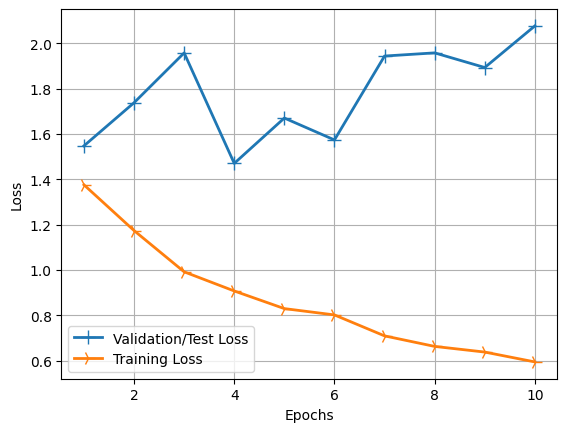

In [51]:


history_dict = history.history

loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values) + 1)

line1 = plt.plot(epochs, val_loss_values, label='Validation/Test Loss')
line2 = plt.plot(epochs, loss_values, label='Training Loss')
plt.setp(line1, linewidth=2.0, marker = '+', markersize=10.0)
plt.setp(line2, linewidth=2.0, marker = '4', markersize=10.0)
plt.xlabel('Epochs') 
plt.ylabel('Loss')
plt.grid(True)
plt.legend()
plt.show()

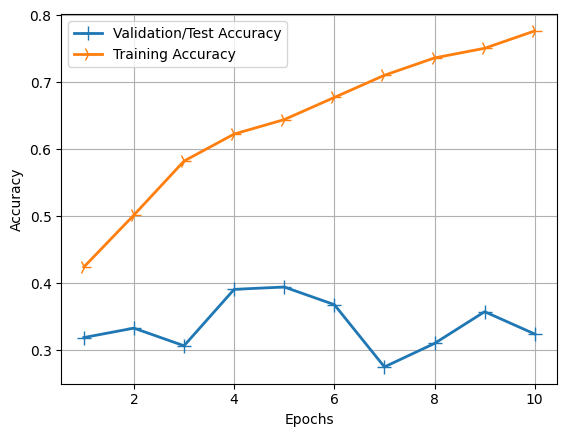

In [52]:
history_dict = history.history

acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(loss_values) + 1)

line1 = plt.plot(epochs, val_acc_values, label='Validation/Test Accuracy')
line2 = plt.plot(epochs, acc_values, label='Training Accuracy')
plt.setp(line1, linewidth=2.0, marker = '+', markersize=10.0)
plt.setp(line2, linewidth=2.0, marker = '4', markersize=10.0)
plt.xlabel('Epochs') 
plt.ylabel('Accuracy')
plt.grid(True)
plt.legend()
plt.show()